# Iniciando testes da fase de treinamento

### Importação de módulos

In [523]:
%%capture
!pip install comet_ml
!pip install xgboost

In [524]:
import comet_ml
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os

### Montagem do drive

In [525]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [526]:
dirpath = '/content/drive/My Drive/supervised-learning-studies'
filename = 'df_analise.pkl'
file_path = os.path.join(dirpath, filename)

# O arquivo deve ser lido de um csv devido ao formato das casas decimais, que usam ponto ao invés de vírgula. O Excel, por exemplo, não consegue ler esse formato corretamente.
df = pd.read_pickle(file_path)
df['target'] = df['resistencia'].copy()
df.drop(columns=['resistencia'], inplace=True)


In [527]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [528]:
# 1. Separa 70% para treino e 30% para o resto (mantendo a proporção da coluna 'bins')
df_train, df_temp = train_test_split(
    df,
    test_size=0.3, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 30% restantes, divide em Teste (2/3) e Validação (1/3)
# Isso resulta em 20% do total para Teste e 10% para Validação
df_test, df_val = train_test_split(
    df_temp, 
    test_size=0.3333, 
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [529]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

cimento               0
escoriadealtoforno    0
cinzasvolantes        0
agua                  0
superplastificante    0
agregadogrosso        0
agregadofino          0
idade                 0
dtype: int64


In [ ]:
comet_ml.login(
    api_key="YOUR_COMET_API_KEY",
    project_name="supervised-learning-studies",
    workspace="marcos-vinicius-belo-da-silva"
)

COMET INFO: Valid Comet API Key saved in /content/drive/MyDrive/.comet.config (set COMET_CONFIG to change where it is saved).


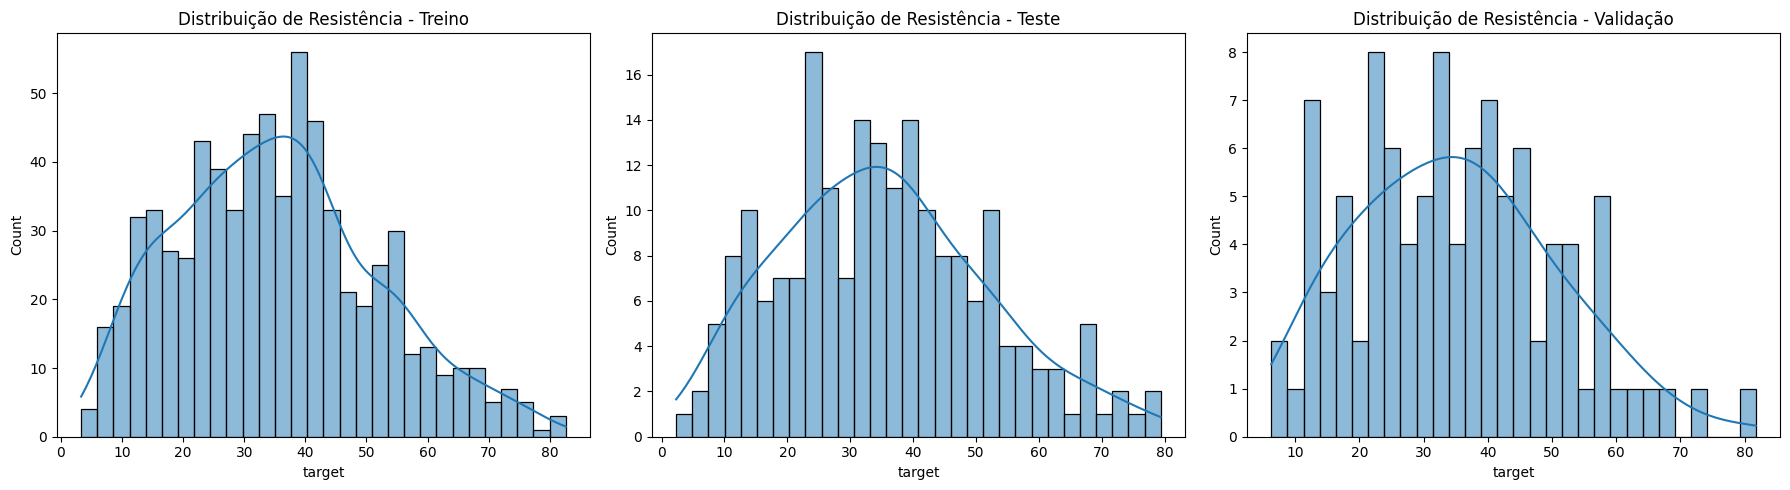

In [531]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Resistência - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Resistência - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Resistência - Validação')
plt.tight_layout()
plt.show()

### Validação dos dados de teste, treino e validação

In [532]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (703, 8)
X_test shape: (201, 8)
X_val shape: (101, 8)

X_train
cimento: float64 (NAs: 0)
escoriadealtoforno: float64 (NAs: 0)
cinzasvolantes: float64 (NAs: 0)
agua: float64 (NAs: 0)
superplastificante: float64 (NAs: 0)
agregadogrosso: float64 (NAs: 0)
agregadofino: float64 (NAs: 0)
idade: int64 (NAs: 0)

X_test
cimento: float64 (NAs: 0)
escoriadealtoforno: float64 (NAs: 0)
cinzasvolantes: float64 (NAs: 0)
agua: float64 (NAs: 0)
superplastificante: float64 (NAs: 0)
agregadogrosso: float64 (NAs: 0)
agregadofino: float64 (NAs: 0)
idade: int64 (NAs: 0)

X_val
cimento: float64 (NAs: 0)
escoriadealtoforno: float64 (NAs: 0)
cinzasvolantes: float64 (NAs: 0)
agua: float64 (NAs: 0)
superplastificante: float64 (NAs: 0)
agregadogrosso: float64 (NAs: 0)
agregadofino: float64 (NAs: 0)
idade: int64 (NAs: 0)



### Validação dos targets

In [533]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (703,)
y_test shape: (201,)
y_val shape: (101,)

y_train
target: float64 (NAs: 0)

y_test
target: float64 (NAs: 0)

y_val
target: float64 (NAs: 0)



In [534]:
experiment = comet_ml.start()

hyper_params = {
    "n_estimators": 200,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "rmse"
}

experiment.log_parameters(hyper_params)

model = XGBRegressor(**hyper_params)

COMET INFO: An experiment with the same configuration options is already running and will be reused.


In [535]:
%%time
model.fit(X_train, y_train)

CPU times: user 488 ms, sys: 6.98 ms, total: 495 ms
Wall time: 270 ms


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [536]:
%%capture
experiment.display("charts")
# make predictions
y_pred = model.predict(X_test)

print(type(X_test))

debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

experiment.log_table("prediction_debug_table.csv", debug_df)

Text(0.5, 1.0, 'Distribuição dos Resíduos')

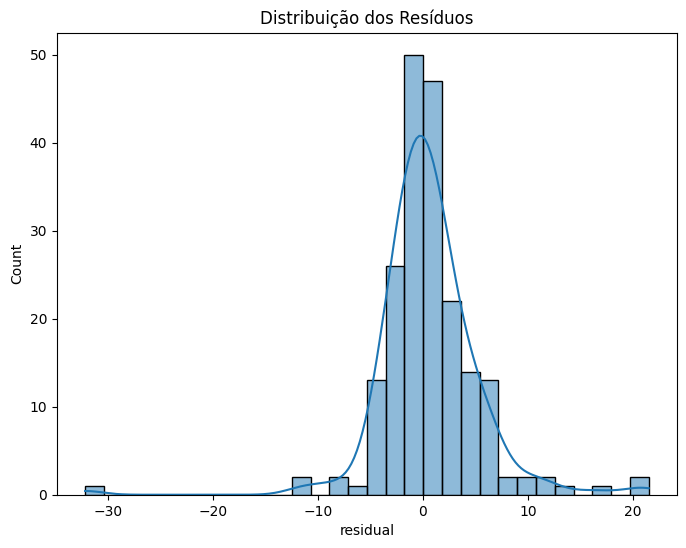

In [537]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos")

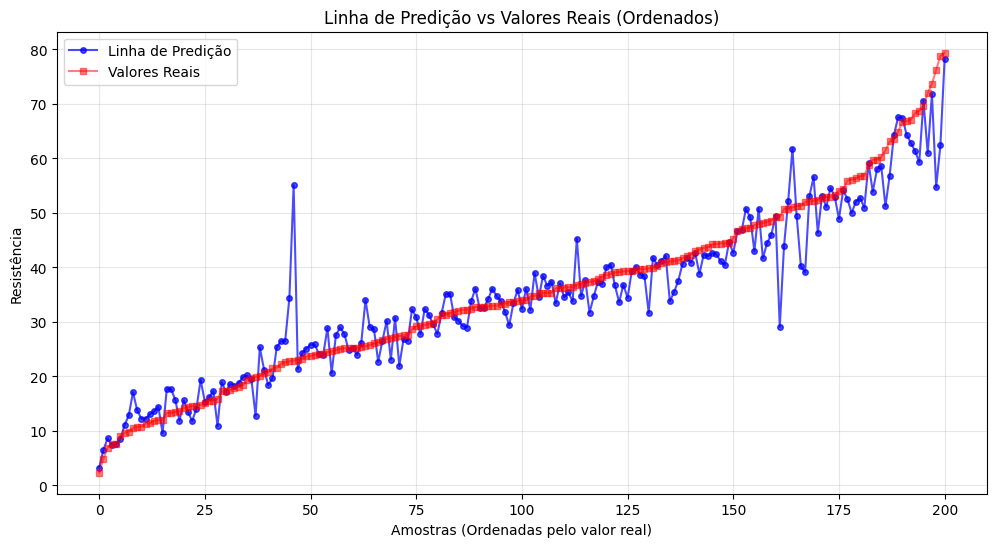

In [538]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [539]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 4.8864
mean_absolute_error: 3.0816
mean_absolute_percentage_error: 0.1023
R² Score: 91.0861


In [540]:
model.save_model(os.path.join(dirpath, "melhor_modelo_resistencia.json"))